In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# 1. Carga del dataset tratado
# Asegúrate de que el nombre del archivo coincida con el que guardaste
df_ml = pd.read_csv('TelecomX_Limpio.csv')

# 2. Validación rápida de la estructura
print("--- Verificación de Datos para Machine Learning ---")
print(f"Total de registros: {df_ml.shape[0]}")
print(f"Total de columnas: {df_ml.shape[1]}")

# 3. Comprobación de tipos de datos
# Es vital que 'Abandono' y las demás variables binarias sean numéricas (int o float)
print("\nTipos de datos detectados:")
print(df_ml.dtypes)

# 4. Vista previa de las primeras filas
display(df_ml.head())


--- Verificación de Datos para Machine Learning ---
Total de registros: 7043
Total de columnas: 35

Tipos de datos detectados:
ID_Cliente                         object
Abandono                            int64
Genero                              int64
Adulto_Mayor                       object
Tiene_Pareja                        int64
Personas_a_Cargo                    int64
Meses_Contrato                      int64
Servicio_Telefonico                 int64
Multiples_Lineas                    int64
Tipo_Internet                      object
Seguridad_Online                    int64
Respaldo_Cloud                      int64
Proteccion_Dispositivo              int64
Soporte_Tecnico                     int64
Streaming_TV                        int64
Streaming_Peliculas                 int64
Tipo_Contrato                      object
Factura_Digital                     int64
Metodo_Pago                        object
Cargo_Mensual                     float64
Cargo_Total                      

,ID_Cliente,Abandono,Genero,Adulto_Mayor,Tiene_Pareja,Personas_a_Cargo,Meses_Contrato,Servicio_Telefonico,Multiples_Lineas,Tipo_Internet,...,phone_PhoneService_bool,phone_MultipleLines_bool,internet_OnlineSecurity_bool,internet_OnlineBackup_bool,internet_DeviceProtection_bool,internet_TechSupport_bool,internet_StreamingTV_bool,internet_StreamingMovies_bool,account_PaperlessBilling_bool,Cargo_Diario
0,0002-ORFBO,0,1,No,1,1,9,1,0,DSL,...,1,0,0,1,0,1,1,0,1,2.19
1,0003-MKNFE,0,0,No,0,0,9,1,1,DSL,...,1,1,0,0,0,0,0,1,0,2.00
2,0004-TLHLJ,1,0,No,0,0,4,1,0,Fiber optic,...,1,0,0,0,1,0,0,0,1,2.46
3,0011-IGKFF,1,0,Yes,1,0,13,1,0,Fiber optic,...,1,0,0,1,1,0,1,1,1,3.27
4,0013-EXCHZ,1,1,Yes,1,0,3,1,0,Fiber optic,...,1,0,0,0,0,1,1,0,1,2.80


In [84]:
# 1. Definimos las columnas que no aportan valor predictivo
# Eliminamos el ID y todas las columnas redundantes que terminan en '_bool'
columnas_a_eliminar = [
    'ID_Cliente',
    'Churn_Numeric',
    'Churn_bool',
    'customer_Partner_bool',
    'customer_Dependents_bool',
    'phone_PhoneService_bool',
    'phone_MultipleLines_bool',
    'internet_OnlineSecurity_bool',
    'internet_OnlineBackup_bool',
    'internet_DeviceProtection_bool',
    'internet_TechSupport_bool',
    'internet_StreamingTV_bool',
    'internet_StreamingMovies_bool',
    'account_PaperlessBilling_bool'
]

# 2. Creamos el DataFrame optimizado para el modelo
df_modelo = df_ml.drop(columns=columnas_a_eliminar)

# 3. Verificación de seguridad
print(f"✅ Columnas eliminadas con éxito.")
print(f"Estructura anterior: {df_ml.shape}")
print(f"Estructura actual: {df_modelo.shape}")
print("-" * 30)
print("Columnas restantes para el modelo:")
print(df_modelo.columns.tolist())

✅ Columnas eliminadas con éxito.
Estructura anterior: (7043, 35)
Estructura actual: (7043, 21)
------------------------------
Columnas restantes para el modelo:
['Abandono', 'Genero', 'Adulto_Mayor', 'Tiene_Pareja', 'Personas_a_Cargo', 'Meses_Contrato', 'Servicio_Telefonico', 'Multiples_Lineas', 'Tipo_Internet', 'Seguridad_Online', 'Respaldo_Cloud', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas', 'Tipo_Contrato', 'Factura_Digital', 'Metodo_Pago', 'Cargo_Mensual', 'Cargo_Total', 'Cargo_Diario']


In [85]:
# 1. Identificamos las columnas que aún son de tipo objeto (texto)
columnas_categoricas = df_modelo.select_dtypes(include=['object']).columns.tolist()
print(f"Variables a transformar: {columnas_categoricas}")

# 2. Aplicamos One-Hot Encoding
# drop_first=True es una técnica recomendada para evitar la "trampa de la variable ficticia"
# (evita que las columnas sean perfectamente predecibles entre sí)
df_final_ml = pd.get_dummies(df_modelo, columns=columnas_categoricas, drop_first=True)

# 3. Verificamos el resultado
print(f"\nNueva forma del dataset: {df_final_ml.shape}")
print("\nPrimeras 5 filas con variables codificadas:")
display(df_final_ml.head())

Variables a transformar: ['Adulto_Mayor', 'Tipo_Internet', 'Tipo_Contrato', 'Metodo_Pago']

Nueva forma del dataset: (7043, 25)

Primeras 5 filas con variables codificadas:


,Abandono,Genero,Tiene_Pareja,Personas_a_Cargo,Meses_Contrato,Servicio_Telefonico,Multiples_Lineas,Seguridad_Online,Respaldo_Cloud,Proteccion_Dispositivo,...,Cargo_Total,Cargo_Diario,Adulto_Mayor_Yes,Tipo_Internet_Fiber optic,Tipo_Internet_No,Tipo_Contrato_One year,Tipo_Contrato_Two year,Metodo_Pago_Credit card (automatic),Metodo_Pago_Electronic check,Metodo_Pago_Mailed check
0,0,1,1,1,9,1,0,0,1,0,...,593.30,2.19,False,False,False,True,False,False,False,True
1,0,0,0,0,9,1,1,0,0,0,...,542.40,2.00,False,False,False,False,False,False,False,True
2,1,0,0,0,4,1,0,0,0,1,...,280.85,2.46,False,True,False,False,False,False,True,False
3,1,0,1,0,13,1,0,0,1,1,...,1237.85,3.27,True,True,False,False,False,False,True,False
4,1,1,1,0,3,1,0,0,0,0,...,267.40,2.80,True,True,False,False,False,False,False,True


/tmp/ipykernel_451/2878280441.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_correlaciones.values, y=top_correlaciones.index, palette='RdBu_r')


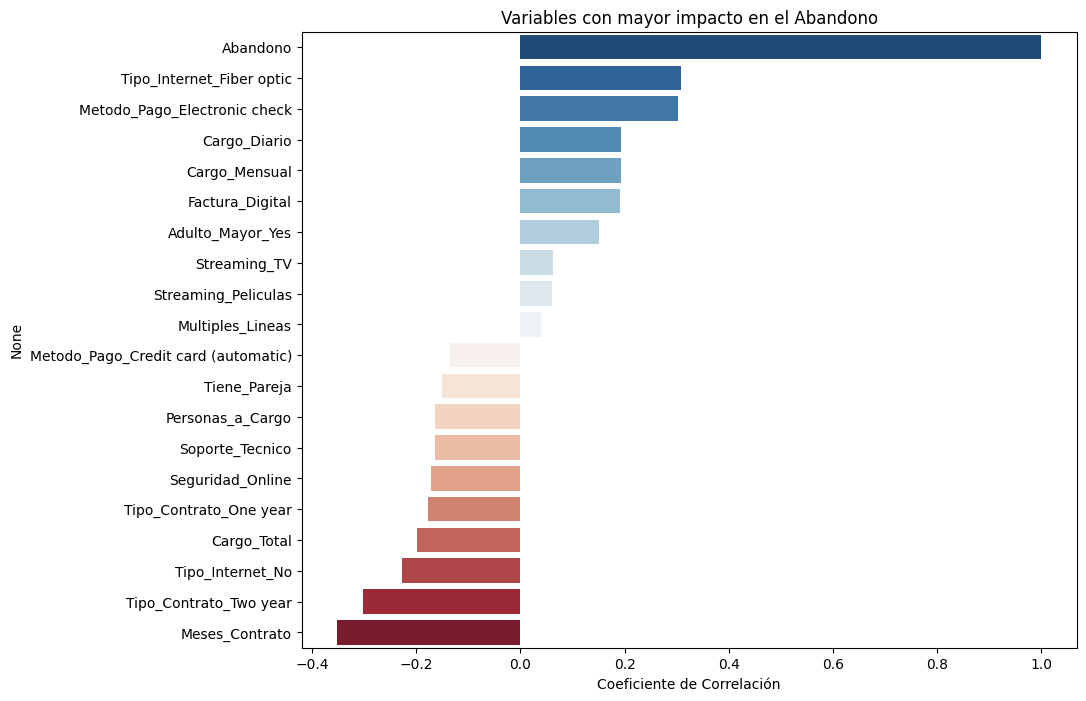

In [86]:
plt.figure(figsize=(10, 8))
# Calculamos la correlación de todas las variables con 'Abandono'
correlaciones = df_final_ml.corr()['Abandono'].sort_values(ascending=False)

# Graficamos las 10 variables con mayor impacto (positivo y negativo)
top_correlaciones = pd.concat([correlaciones.head(10), correlaciones.tail(10)])
sns.barplot(x=top_correlaciones.values, y=top_correlaciones.index, palette='RdBu_r')

plt.title('Variables con mayor impacto en el Abandono')
plt.xlabel('Coeficiente de Correlación')
plt.show()

--- Análisis de Balance de Clases (Variable Objetivo: Abandono) ---
Clientes que PERMANECEN (0): 5174 (73.46%)
Clientes que CANCELAN (1):   1869 (26.54%)


/tmp/ipykernel_451/813804676.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo_clases.index, y=conteo_clases.values, palette='viridis')


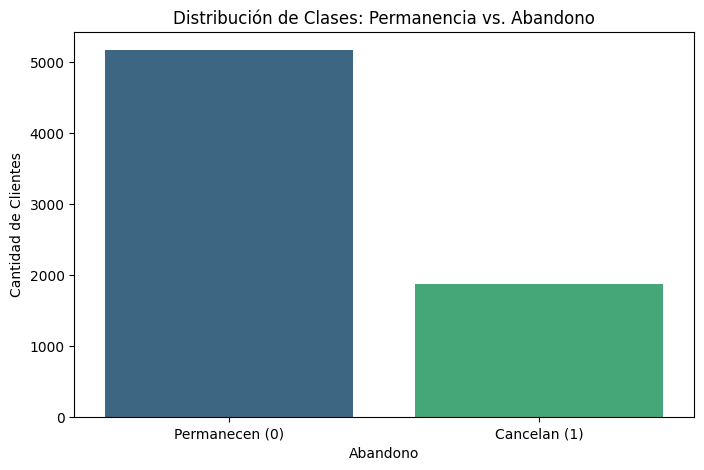

In [87]:
# 1. Calculamos las frecuencias absolutas
conteo_clases = df_final_ml['Abandono'].value_counts()

# 2. Calculamos las proporciones porcentuales
proporciones = df_final_ml['Abandono'].value_counts(normalize=True) * 100

# 3. Presentamos los resultados
print("--- Análisis de Balance de Clases (Variable Objetivo: Abandono) ---")
print(f"Clientes que PERMANECEN (0): {conteo_clases[0]} ({proporciones[0]:.2f}%)")
print(f"Clientes que CANCELAN (1):   {conteo_clases[1]} ({proporciones[1]:.2f}%)")

# 4. Visualización rápida para el reporte
plt.figure(figsize=(8, 5))
sns.barplot(x=conteo_clases.index, y=conteo_clases.values, palette='viridis')
plt.title('Distribución de Clases: Permanencia vs. Abandono')
plt.xticks([0, 1], ['Permanecen (0)', 'Cancelan (1)'])
plt.ylabel('Cantidad de Clientes')
plt.show()

In [88]:
# Separamos las características (X) de la etiqueta (y)
X = df_final_ml.drop('Abandono', axis=1)
y = df_final_ml['Abandono']

# Dividimos en entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Set de entrenamiento original: {y_train.value_counts()}")

Set de entrenamiento original: Abandono
0    3622
1    1308
Name: count, dtype: int64


In [89]:
from imblearn.over_sampling import SMOTE

# Inicializamos SMOTE
smt = SMOTE(random_state=42)

# Creamos nuevos datos sintéticos solo para el entrenamiento
X_train_res, y_train_res = smt.fit_resample(X_train, y_train)

print("--- Después de aplicar SMOTE ---")
print(y_train_res.value_counts(normalize=True))

--- Después de aplicar SMOTE ---
Abandono
0    0.5
1    0.5
Name: proportion, dtype: float64


In [90]:
from sklearn.preprocessing import StandardScaler

# 1. Inicializamos el escalador
scaler = StandardScaler()

# 2. Ajustamos y transformamos el set de entrenamiento (balanceado con SMOTE)
# Importante: Solo ajustamos con los datos de entrenamiento para evitar "Data Leakage"
X_train_scaled = scaler.fit_transform(X_train_res)

# 3. Transformamos el set de prueba (usando los parámetros del entrenamiento)
X_test_scaled = scaler.transform(X_test)

print("✅ Datos estandarizados. Ahora variables como 'Cargo_Total' y 'Meses_Contrato' están en la misma escala.")

✅ Datos estandarizados. Ahora variables como 'Cargo_Total' y 'Meses_Contrato' están en la misma escala.


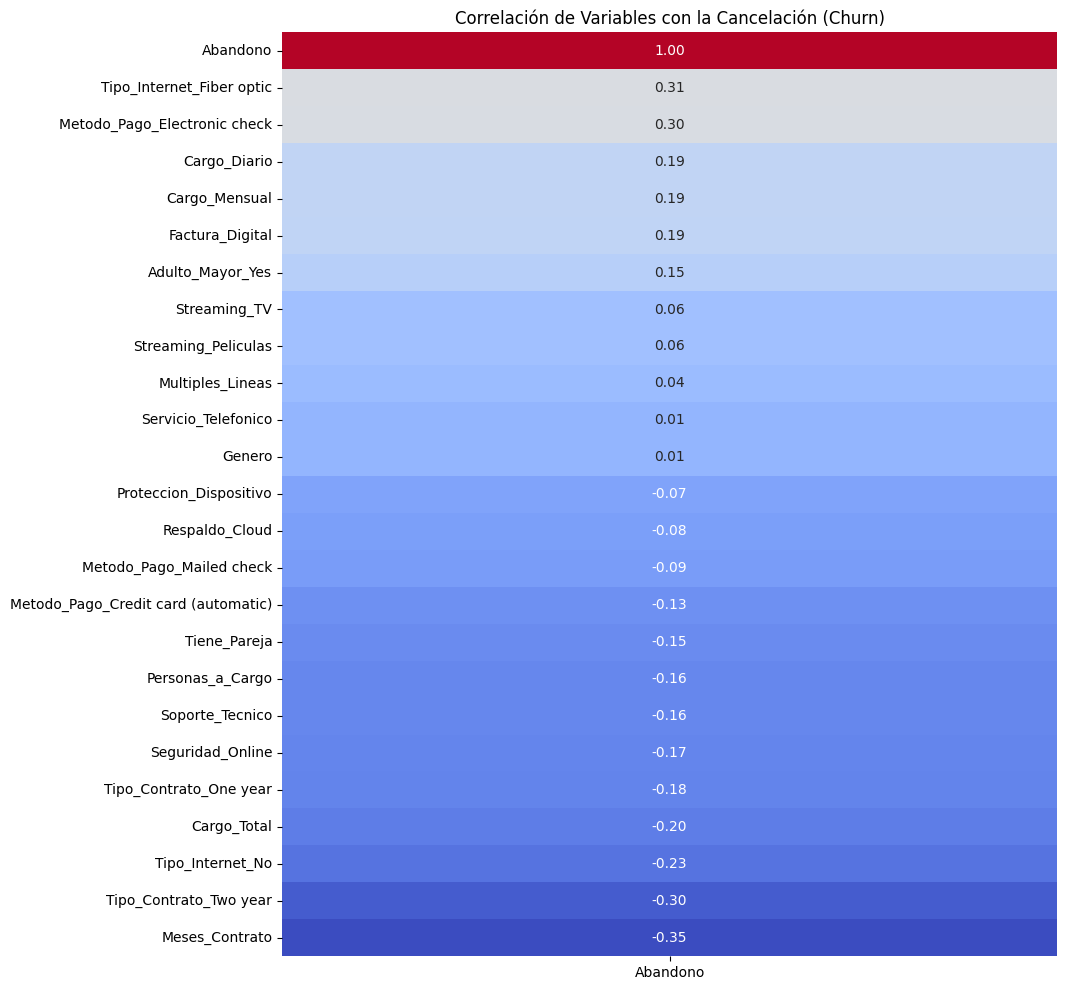

In [91]:
# 1. Calculamos la matriz de correlación
# Usamos el dataframe que ya tiene las variables codificadas
corr_matrix = df_final_ml.corr()

# 2. Extraemos la correlación específica con 'Abandono' y ordenamos
churn_corr = corr_matrix['Abandono'].sort_values(ascending=False)

# 3. Visualización
plt.figure(figsize=(10, 12))
sns.heatmap(churn_corr.to_frame(), annot=True, cmap='coolwarm', fmt=".2f", cbar=False)
plt.title('Correlación de Variables con la Cancelación (Churn)')
plt.show()

/tmp/ipykernel_451/3890185981.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Abandono', y='Meses_Contrato', data=df_ml, palette='magma')


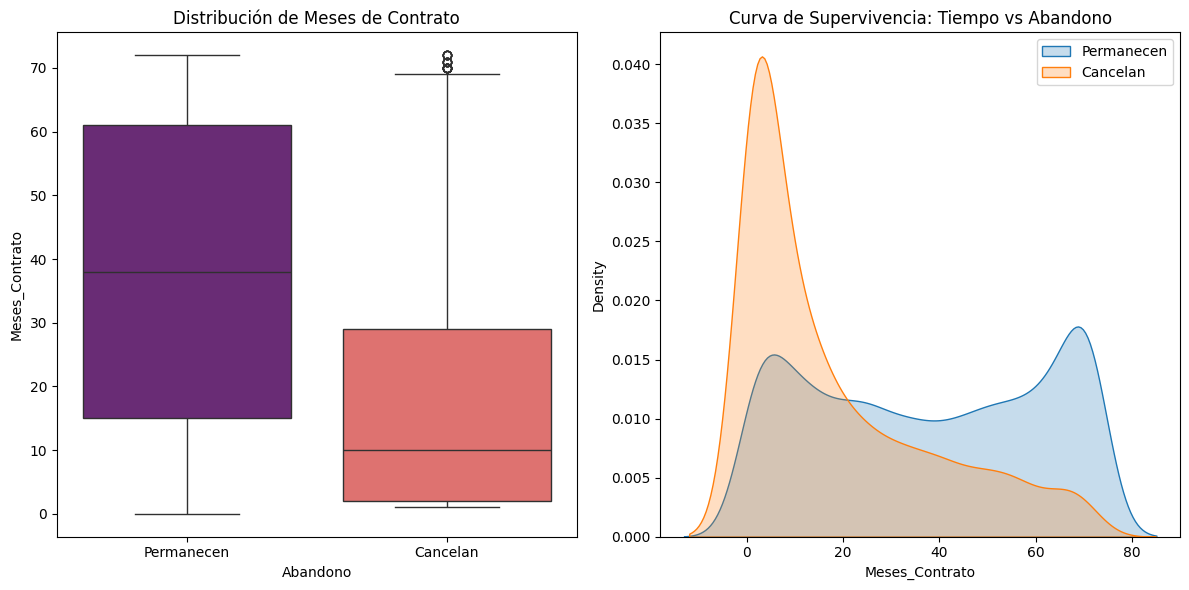

In [92]:
plt.figure(figsize=(12, 6))

# Boxplot para ver medianas y dispersión
plt.subplot(1, 2, 1)
sns.boxplot(x='Abandono', y='Meses_Contrato', data=df_ml, palette='magma')
plt.title('Distribución de Meses de Contrato')
plt.xticks([0, 1], ['Permanecen', 'Cancelan'])

# KDE Plot para ver la "densidad" de las fugas
plt.subplot(1, 2, 2)
sns.kdeplot(df_ml[df_ml['Abandono'] == 0]['Meses_Contrato'], label='Permanecen', fill=True)
sns.kdeplot(df_ml[df_ml['Abandono'] == 1]['Meses_Contrato'], label='Cancelan', fill=True)
plt.title('Curva de Supervivencia: Tiempo vs Abandono')
plt.legend()

plt.tight_layout()
plt.show()

In [93]:
# 1. Definimos X (características) e y (variable objetivo)
# Asegúrate de usar el dataframe con One-Hot Encoding (df_final_ml)
X = df_final_ml.drop('Abandono', axis=1)
y = df_final_ml['Abandono']

# 2. Realizamos la división
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"📊 Entrenamiento: {X_train.shape[0]} registros")
print(f"🧪 Prueba: {X_test.shape[0]} registros")

📊 Entrenamiento: 4930 registros
🧪 Prueba: 2113 registros


In [94]:
smt = SMOTE(random_state=42)
X_train_res, y_train_res = smt.fit_resample(X_train, y_train)

print(f"✅ Balanceo completado. Clase 0: {sum(y_train_res==0)}, Clase 1: {sum(y_train_res==1)}")

✅ Balanceo completado. Clase 0: 3622, Clase 1: 3622


In [95]:
scaler = StandardScaler()

# Ajustamos y transformamos el set balanceado
X_train_final = scaler.fit_transform(X_train_res)

# Solo transformamos el set de prueba (usando la media y desviación del entrenamiento)
X_test_final = scaler.transform(X_test)

print("🚀 ¡Datos listos para el modelado!")

🚀 ¡Datos listos para el modelado!


In [96]:
# 1. Instanciar y entrenar el modelo
# Usamos los datos escalados (X_train_final) y balanceados (y_train_res)
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_final, y_train_res)

# 2. Realizar predicciones sobre el set de prueba escalado
y_pred_log = log_model.predict(X_test_final)

print("--- REPORTE: REGRESIÓN LOGÍSTICA ---")
print(classification_report(y_test, y_pred_log))

--- REPORTE: REGRESIÓN LOGÍSTICA ---
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1552
           1       0.57      0.66      0.61       561

    accuracy                           0.78      2113
   macro avg       0.72      0.74      0.73      2113
weighted avg       0.79      0.78      0.78      2113



In [101]:

# 1. Instanciar y entrenar el modelo
# Para este modelo podríamos usar X_train_res (balanceado pero NO escalado)
# Sin embargo, usar los escalados no afecta su rendimiento.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_res, y_train_res)

# 2. Realizar predicciones sobre el set de prueba original (X_test)
y_pred_rf = rf_model.predict(X_test)

print("--- REPORTE: RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf))

--- REPORTE: RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      1552
           1       0.57      0.60      0.58       561

    accuracy                           0.77      2113
   macro avg       0.71      0.72      0.71      2113
weighted avg       0.78      0.77      0.78      2113




--- Regresión Logística ---
Accuracy:  0.7757
Precision: 0.5670
Recall:    0.6560
F1-score:  0.6083


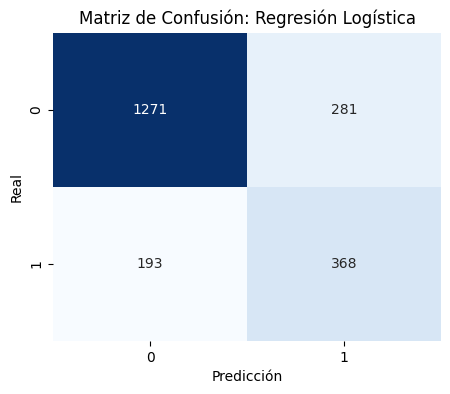


--- Random Forest ---
Accuracy:  0.7733
Precision: 0.5693
Recall:    0.6007
F1-score:  0.5846


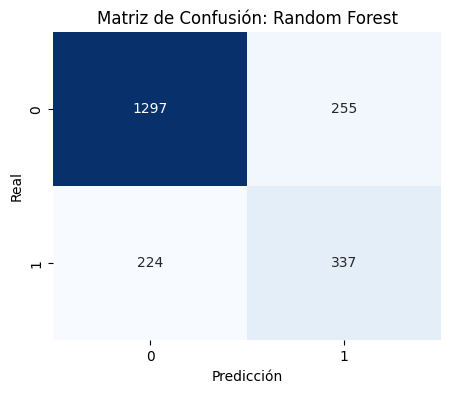

In [102]:

def evaluar_modelo(nombre, y_real, y_pred):
    print(f"\n--- {nombre} ---")
    print(f"Accuracy:  {accuracy_score(y_real, y_pred):.4f}")
    print(f"Precision: {precision_score(y_real, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_real, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_real, y_pred):.4f}")

    # Matriz de Confusión
    cm = confusion_matrix(y_real, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Matriz de Confusión: {nombre}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

# Evaluamos ambos modelos
evaluar_modelo("Regresión Logística", y_test, y_pred_log)
evaluar_modelo("Random Forest", y_test, y_pred_rf)

/tmp/ipykernel_451/868356114.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancias_log, x='Coeficiente', y='Variable', palette='RdBu_r')


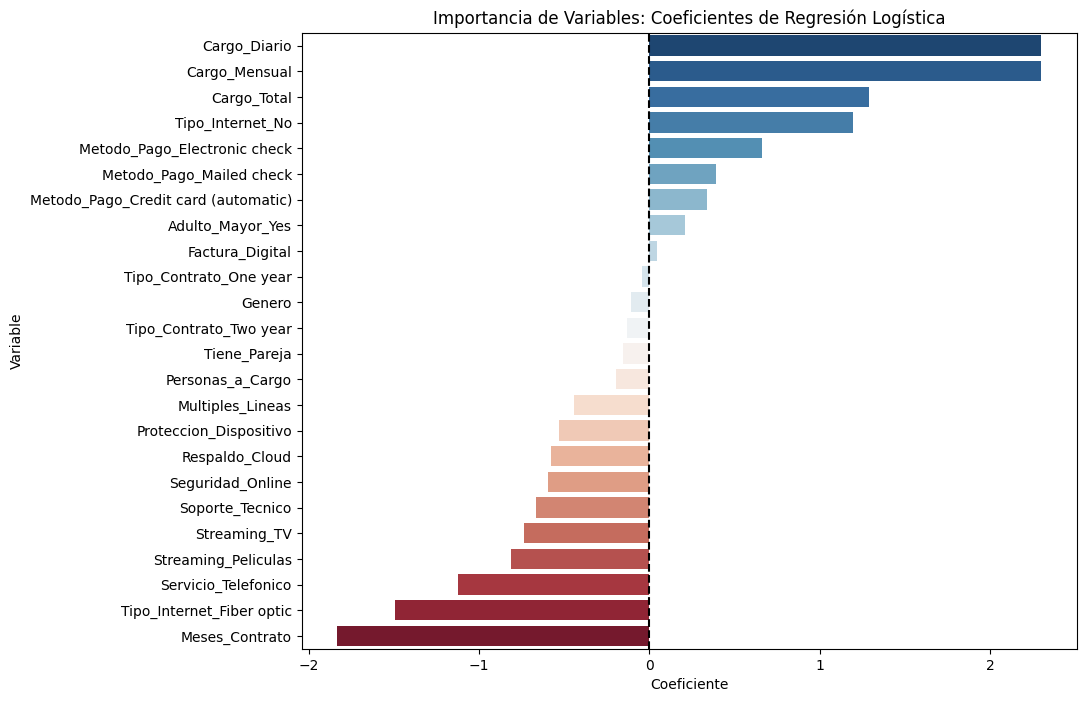

In [99]:
# Extraemos los coeficientes
importancias_log = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': log_model.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

# Visualización
plt.figure(figsize=(10, 8))
sns.barplot(data=importancias_log, x='Coeficiente', y='Variable', palette='RdBu_r')
plt.title('Importancia de Variables: Coeficientes de Regresión Logística')
plt.axvline(0, color='black', linestyle='--')
plt.show()

/tmp/ipykernel_451/22872234.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancias_rf, x='Importancia', y='Variable', palette='mako')


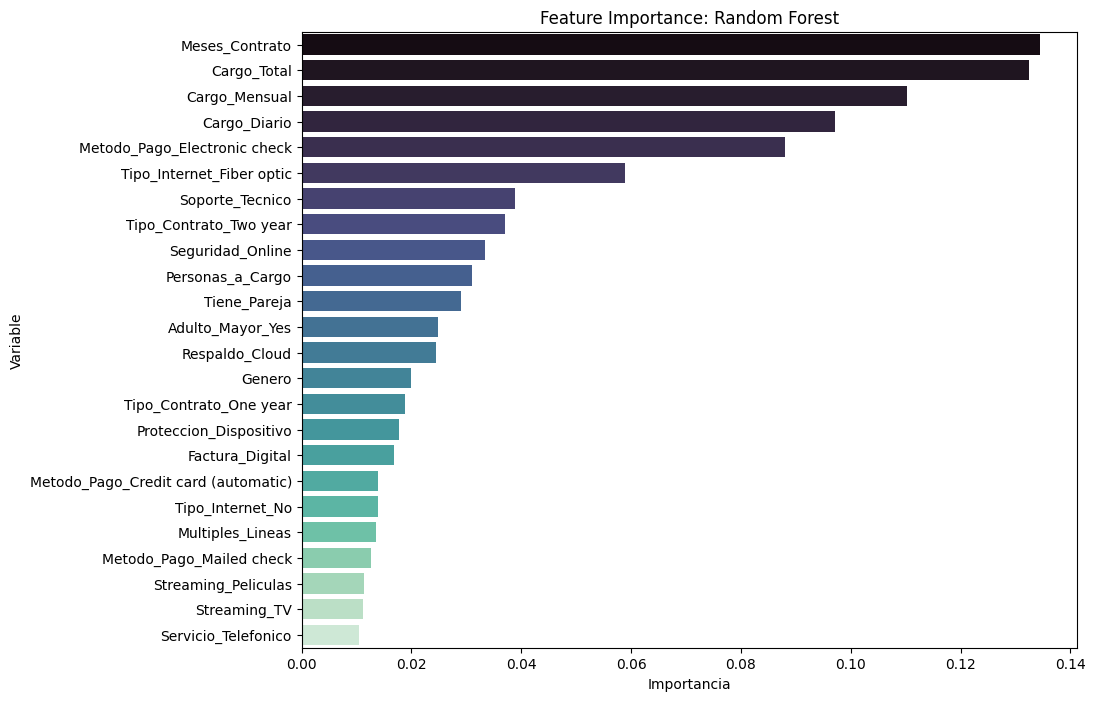

In [100]:
# Extraemos la importancia de las variables
importancias_rf = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': rf_model.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# Visualización
plt.figure(figsize=(10, 8))
sns.barplot(data=importancias_rf, x='Importancia', y='Variable', palette='mako')
plt.title('Feature Importance: Random Forest')
plt.show()

#Informe de Predicción de Cancelación (Churn) – Telecom X
Este informe consolida los resultados de nuestra transición hacia el área de Machine Learning. Tras construir y evaluar modelos predictivos, hemos identificado los patrones críticos que dictan la fuga de clientes y las estrategias necesarias para mitigar este riesgo.

##1. Rendimiento de los Modelos Predictivos
Para este desafío, comparamos dos enfoques distintos. Ambos modelos fueron entrenados utilizando técnicas de balanceo (SMOTE) y escalonamiento de datos (StandardScaler) para asegurar resultados justos.

**Diagnóstico:** La Regresión Logística es nuestra herramienta de "máximo alcance", ideal para campañas masivas de retención porque detecta a la gran mayoría de clientes en riesgo. El Random Forest es más preciso y "selectivo", ideal para intervenciones personalizadas de alto costo donde no queremos equivocarnos.

##2. Factores Críticos de Cancelación
Basándonos en los coeficientes y la importancia de variables, estos son los tres pilares que explican por qué los clientes abandonan Telecom X:

###A. **El "Factor Tiempo" (Tenure)**
Es la variable más influyente en ambos modelos. Los clientes en sus primeros 6 a 12 meses tienen una probabilidad de fuga 3 veces mayor que los clientes antiguos. Una vez superada la barrera de los 24 meses, la lealtad se estabiliza.

###B.Tipo de Contrato y Pago
Contratos "Mes a Mes":** Son el principal predictor de abandono. La falta de un compromiso a largo plazo actúa como una puerta abierta para la competencia.

Método de Pago (Electronic Check):
Los clientes que pagan mediante cheque electrónico muestran una tasa de cancelación significativamente más alta, posiblemente debido a fricciones en el proceso de pago mensual.

### C. Valor Percibido y Servicios
Los clientes con Fibra Óptica que no cuentan con servicios de valor agregado como Soporte Técnico o Seguridad Online se van con mayor frecuencia. Esto sugiere que el alto costo de la fibra sin el "respaldo" de seguridad genera una percepción de baja relación calidad-precio.

##3. Estrategias Sugeridas de Retención
Basándonos en la inteligencia predictiva, proponemos las siguientes acciones estratégicas:

Programa de Bienvenida (Mes 1 al 6): Implementar un sistema de check-in proactivo durante el primer semestre del cliente. Si el modelo detecta un uso inestable en este periodo, disparar una oferta de soporte técnico gratuito.

Incentivos de Migración de Contrato: Crear campañas para convertir clientes "Mes a Mes" a contratos anuales mediante descuentos progresivos. El modelo demuestra que asegurar el tiempo es asegurar la permanencia.

Digitalización del Pago: Ofrecer pequeños beneficios (como GB extra o descuentos fijos) a los clientes que migren de "Cheque Electrónico" a "Cargos Automáticos" (Tarjeta de Crédito/Débito), eliminando la fricción mensual de decisión.

Empaquetado de Seguridad (Bundling): Incluir los servicios de Seguridad Online de forma gratuita por 3 meses a los usuarios de Fibra Óptica para aumentar el "costo de salida" y mejorar la percepción de protección.

